In [ ]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pymc",
#   "seaborn",
# ]
# ///


This notebook is taken almost verbatim from the pymc3 documentation (https://docs.pymc.io/notebooks/gaussian-mixture-model-advi.html) . Its a very good illustration of what needs to be done to

- marginalize over discretes for ADVI
- deal with 2D mixtures
- get MCMC done as well with a custom density

Thus it provides an illustration of many concepts that will come useful.

In [2]:
%matplotlib inline

import pymc as pm
import pytensor.tensor as pt
from pytensor.tensor.nlinalg import det
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
sns.set_style('whitegrid')
sns.set_context('poster')

## Generate some data

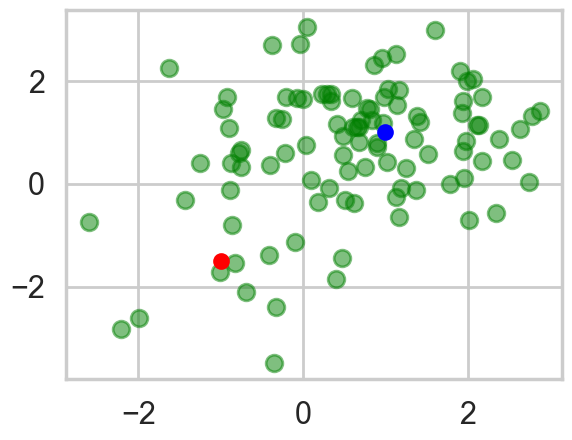

In [3]:
n_samples = 100
# we can use this to set up the pseodorandom number appropriately to communicate results reliably
rng = np.random.RandomState(123)
ms = np.array([[-1, -1.5], [1, 1]])
ps = np.array([0.2, 0.8])

zs = np.array([rng.multinomial(1, ps) for _ in range(n_samples)]).T
xs = [z[:, np.newaxis] * rng.multivariate_normal(m, np.eye(2), size=n_samples)
      for z, m in zip(zs, ms)]
data = np.sum(np.dstack(xs), axis=2)

plt.scatter(data[:, 0], data[:, 1], c='g', alpha=0.5)
plt.scatter(ms[0, 0], ms[0, 1], c='r', s=100)
plt.scatter(ms[1, 0], ms[1, 1], c='b', s=100)

In [4]:
zs[0,:].mean(), zs[1,:].mean()

(np.float64(0.13), np.float64(0.87))

## Marginalize discretes

Gaussian mixture models are usually constructed with categorical random variables. However, any discrete rvs does not fit ADVI. Here, class assignment variables are marginalized out, giving weighted sum of the probability for the gaussian components. The log likelihood of the total probability is calculated using logsumexp, which is a standard technique for making this kind of calculation stable. 

In the below code, DensityDist class is used as the likelihood term. The second argument, logp_gmix(mus, pi, np.eye(2)), is a python function which recieves observations (denoted by 'value') and returns the tensor representation of the log-likelihood. 

In [5]:
from pymc.math import logsumexp

# Log likelihood of normal distribution
def logp_normal(mu, tau, value):
    k = tau.shape[0]
    delta = value - mu
    return (-1 / 2.) * (k * pt.log(2 * np.pi) + pt.log(1./det(tau)) +
                         (delta.dot(tau) * delta).sum(axis=1))

# Log likelihood of Gaussian mixture distribution
# Modern pymc DensityDist: logp receives (value, *dist_params)
# Params may have extra batch dims, so flatten them
def logp_gmix(value, mu_0, mu_1, pi):
    pi_flat = pi.flatten()
    mu_0_flat = mu_0.flatten()
    mu_1_flat = mu_1.flatten()
    tau = np.eye(2)
    logps = [pt.log(pi_flat[i]) + logp_normal(mu, tau, value)
             for i, mu in enumerate([mu_0_flat, mu_1_flat])]
    return pt.sum(logsumexp(pt.stacklists(logps), axis=0))


## Sampling

In [6]:
with pm.Model() as model:
    mus = [pm.MvNormal('mu_%d' % i, mu=np.zeros(2), tau=np.eye(2), shape=(2,))
           for i in range(2)]
    pi = pm.Dirichlet('pi', a=0.1 * np.ones(2), shape=(2,))
    xs = pm.DensityDist('x', mus[0], mus[1], pi, logp=logp_gmix, observed=data)

For comparison with ADVI, run MCMC. 

In [7]:
with model:
    trace = pm.sample(1000, chains=2, cores=1)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_0, mu_1, pi]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [8]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_0[0],0.013,0.826,-1.170,1.047,0.563,0.007,3.0,102.0,1.83
mu_0[1],-0.253,1.269,-1.932,1.230,0.878,0.007,3.0,64.0,1.83
mu_1[0],0.003,0.845,-1.217,1.021,0.576,0.006,3.0,109.0,1.83
mu_1[1],-0.253,1.272,-2.002,1.196,0.881,0.006,3.0,74.0,1.83
pi[0],0.501,0.364,0.079,0.927,0.255,0.001,3.0,86.0,1.83
pi[1],0.499,0.364,0.073,0.921,0.255,0.001,3.0,86.0,1.83


Check posterior of component means and weights. We can see that the MCMC samples of the component mean for the lower-left component varied more than the upper-right due to the difference of the sample size of these clusters. 

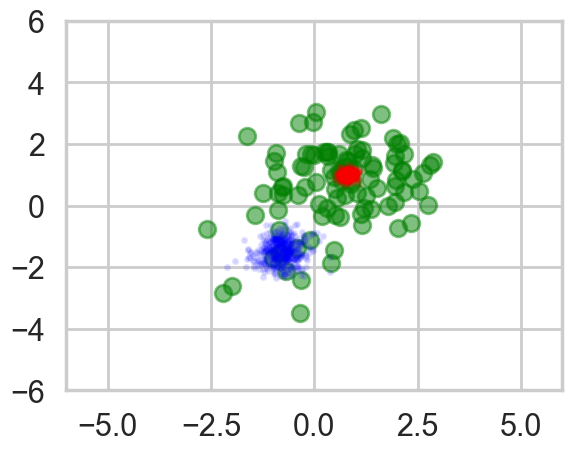

In [9]:
with sns.plotting_context('poster'):
    plt.scatter(data[:, 0], data[:, 1], alpha=0.5, c='g')
    mu_0 = trace.posterior['mu_0'].values.reshape(-1, 2)
    mu_1 = trace.posterior['mu_1'].values.reshape(-1, 2)
    plt.scatter(mu_0[-500:, 0], mu_0[-500:, 1], c="r", s=10, alpha=0.1)
    plt.scatter(mu_1[-500:, 0], mu_1[-500:, 1], c="b", s=10, alpha=0.1)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)

/var/folders/wq/mr3zj9r14dzgjnq9rjx_vqbc0000gn/T/ipykernel_17749/2598148236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[1, 2], y=np.mean(pi_vals[-500:], axis=0),


<Axes: >

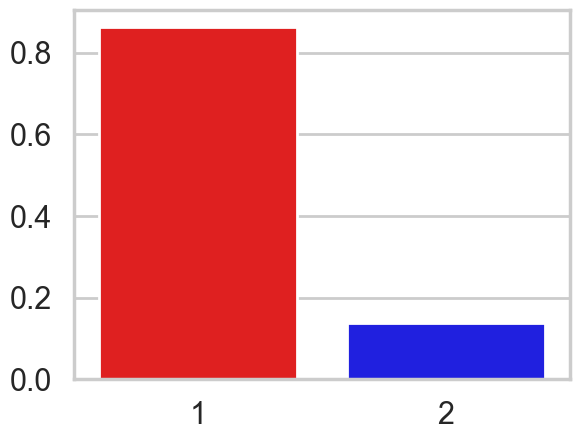

In [10]:
pi_vals = trace.posterior['pi'].values.reshape(-1, 2)
sns.barplot(x=[1, 2], y=np.mean(pi_vals[-500:], axis=0),
            palette=['red', 'blue'])

We can use the same model with ADVI as follows. 

In [11]:
approx = pm.fit(model=model, n=5000)

ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x111495160>


ERROR (pytensor.graph.rewriting.basic): Traceback:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 538, in elemwise_to_scalar
    scalar_inputs = [replacement[inp] for inp in node.inputs]
                     ~~~~~~~~~~~^^^^^
KeyError: mu



/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 348.84


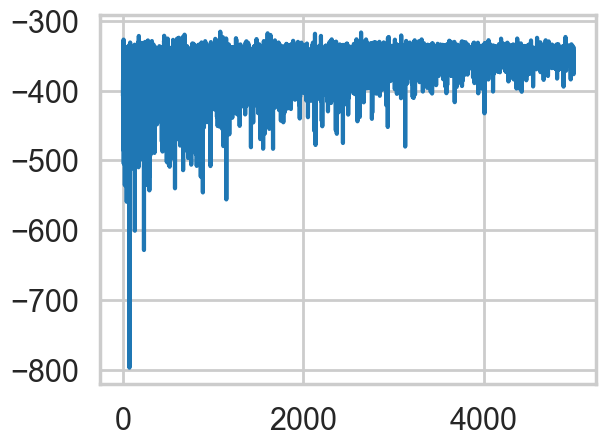

In [12]:
elbo = -approx.hist
plt.plot(elbo)

In [13]:
approx = pm.fit(model=model, n=5000, obj_optimizer=pm.adagrad(learning_rate=1e-1))

ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x111495160>


ERROR (pytensor.graph.rewriting.basic): Traceback:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 538, in elemwise_to_scalar
    scalar_inputs = [replacement[inp] for inp in node.inputs]
                     ~~~~~~~~~~~^^^^^
KeyError: mu



/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 321.61


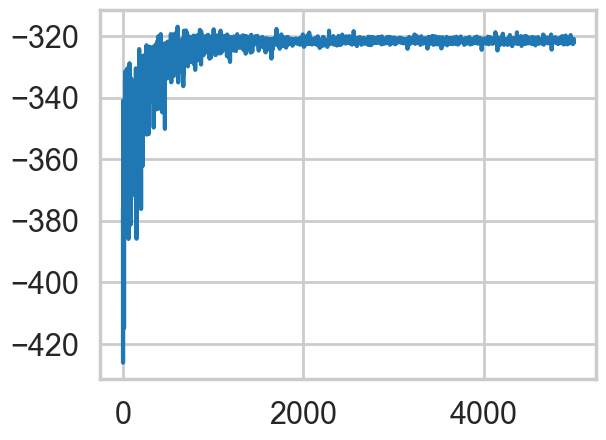

In [14]:
elbo = -approx.hist
plt.plot(elbo)

In [15]:
# In modern pymc, approx.bij is no longer available.
# Use approx.sample() for InferenceData, or inspect mean/std directly.
print("Mean (flat):", approx.mean.eval())
print("Std (flat):", approx.std.eval())
print("Cov diagonal:", np.diag(approx.cov.eval()))

Mean (flat): [-0.78896613 -1.49646697  0.79501754  0.99977293 -0.94516826]
Std (flat): [0.2913095  0.32521268 0.11321497 0.11561967 0.16821171]
Cov diagonal: [0.08486123 0.10576329 0.01281763 0.01336791 0.02829518]


In [16]:
# Not applicable in modern pymc - see mean/std above

In [17]:
# Sample from ADVI approximation to inspect posterior
advi_samps = approx.sample(5000)
print("mu_0 mean:", advi_samps.posterior["mu_0"].mean(dim=["chain", "draw"]).values)
print("mu_1 mean:", advi_samps.posterior["mu_1"].mean(dim=["chain", "draw"]).values)
print("pi mean:", advi_samps.posterior["pi"].mean(dim=["chain", "draw"]).values)

mu_0 mean: [-0.79122781 -1.48940433]
mu_1 mean: [0.79245297 0.99952944]
pi mean: [0.13568764 0.86431236]


'means' and 'sds' are the mean and standard deviations of the variational posterior. Note that these values are in the transformed space, not in the original space. For random variables in the real line, e.g., means of the Gaussian components, no transformation is applied. Then we can see the variational posterior in the original space. 

In [18]:
# Sample from approximation to get InferenceData
advi_samps = approx.sample(5000)
mu_0 = advi_samps.posterior["mu_0"].mean(dim=["chain", "draw"]).values
mu_1 = advi_samps.posterior["mu_1"].mean(dim=["chain", "draw"]).values
sd_0 = advi_samps.posterior["mu_0"].std(dim=["chain", "draw"]).values
sd_1 = advi_samps.posterior["mu_1"].std(dim=["chain", "draw"]).values
mu_0, sd_0, mu_1, sd_1

(array([-0.79096884, -1.49334604]),
 array([0.29297383, 0.32783194]),
 array([0.7957035, 0.9977638]),
 array([0.11276605, 0.11529784]))

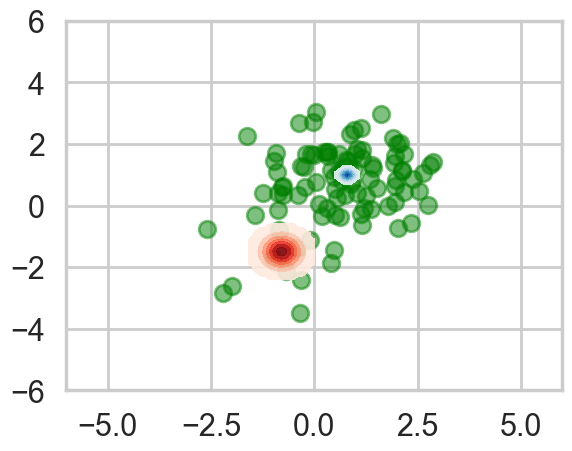

In [19]:
from copy import deepcopy



def logp_normal_np(mu, tau, value):
    # log probability of individual samples
    k = tau.shape[0]
    delta = lambda mu: value - mu
    return (-1 / 2.) * (k * np.log(2 * np.pi) + np.log(1./np.linalg.det(tau)) +
                         (delta(mu).dot(tau) * delta(mu)).sum(axis=1))

def threshold(zz):    
    zz_ = deepcopy(zz)
    zz_[zz < np.max(zz) * 1e-2] = None
    return zz_

def plot_logp_normal(ax, mu, sd, cmap):
    f = lambda value: np.exp(logp_normal_np(mu, np.diag(1 / sd**2), value))
    g = lambda mu, sd: np.arange(mu - 3, mu + 3, .1)
    xx, yy = np.meshgrid(g(mu[0], sd[0]), g(mu[1], sd[1]))
    zz = f(np.vstack((xx.reshape(-1), yy.reshape(-1))).T).reshape(xx.shape)
    ax.contourf(xx, yy, threshold(zz), cmap=cmap, alpha=0.9)
           
with sns.plotting_context('poster'):
    fig, ax = plt.subplots()
    plt.scatter(data[:, 0], data[:, 1], alpha=0.5, c='g')
    plot_logp_normal(ax, mu_0, sd_0, cmap='Reds')
    plot_logp_normal(ax, mu_1, sd_1, cmap='Blues')
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)

In [20]:
[rv.name for rv in model.free_RVs]

['mu_0', 'mu_1', 'pi']

We need to backward-transform 'pi', which is transformed by 'stick_breaking'. Variables that are transformed are not transformed back by the current pymc implementation. This is a gotcha to keep in mind. See https://github.com/pymc-devs/pymc/blob/main/pymc/distributions/transforms.py#L200 for details

In [21]:
# In modern pymc, access the value variable for pi
print("Pi value var:", model.rvs_to_values[model["pi"]])

Pi value var: pi_simplex__


In [22]:
# In modern pymc, we can directly get pi from the InferenceData
pi_mean = advi_samps.posterior["pi"].mean(dim=["chain", "draw"]).values
print("Mean pi:", pi_mean)

Mean pi: [0.13561435 0.86438565]


To demonstrate that ADVI works for large dataset with mini-batch, let's create 100,000 samples from the same mixture distribution. 

(-6.0, 6.0)

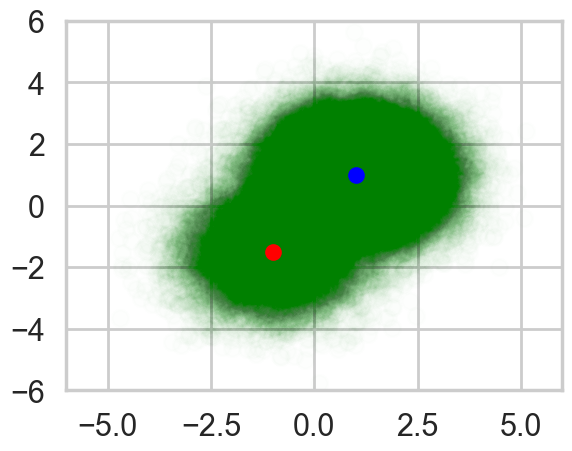

In [23]:
n_samples = 100000

zs = np.array([rng.multinomial(1, ps) for _ in range(n_samples)]).T
xs = [z[:, np.newaxis] * rng.multivariate_normal(m, np.eye(2), size=n_samples)
      for z, m in zip(zs, ms)]
data = np.sum(np.dstack(xs), axis=2)

plt.scatter(data[:, 0], data[:, 1], c='g', alpha=0.008)
plt.scatter(ms[0, 0], ms[0, 1], c='r', s=100)
plt.scatter(ms[1, 0], ms[1, 1], c='b', s=100)
plt.xlim(-6, 6)
plt.ylim(-6, 6)

MCMC takes of ther order of a minute in time, which is 50 times more than on the small dataset.

In [24]:
with pm.Model() as model:
    mus = [pm.MvNormal('mu_%d' % i, mu=np.zeros(2), tau=np.eye(2), shape=(2,))
           for i in range(2)]
    pi = pm.Dirichlet('pi', a=0.1 * np.ones(2), shape=(2,))
    xs = pm.DensityDist('x', mus[0], mus[1], pi, logp=logp_gmix, observed=data)

    trace = pm.sample(1000, chains=2, cores=1)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_0, mu_1, pi]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 283 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Posterior samples are concentrated on the true means, so looks like single point for each component. 

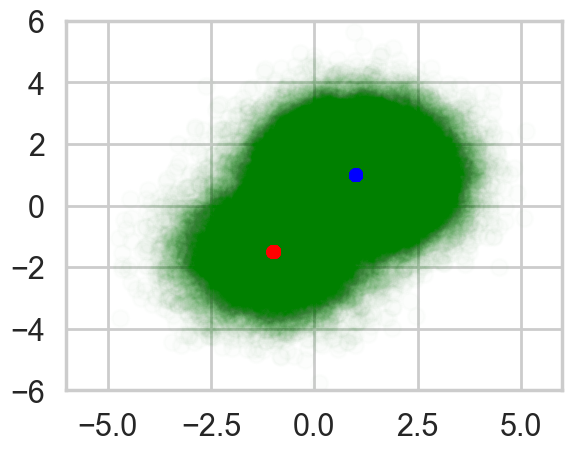

In [25]:
with sns.plotting_context('poster'):
    plt.scatter(data[:, 0], data[:, 1], alpha=0.01, c='g')
    mu_0 = trace.posterior['mu_0'].values.reshape(-1, 2)
    mu_1 = trace.posterior['mu_1'].values.reshape(-1, 2)
    plt.scatter(mu_0[-500:, 0], mu_0[-500:, 1], c="r", s=50)
    plt.scatter(mu_1[-500:, 0], mu_1[-500:, 1], c="b", s=50)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)

For ADVI with mini-batch, put theano tensor on the observed variable of the ObservedRV. The tensor will be replaced with mini-batches. Because of the difference of the size of mini-batch and whole samples, the log-likelihood term should be appropriately scaled. To tell the log-likelihood term, we need to give ObservedRV objects ('minibatch_RVs' below) where mini-batch is put. Also we should keep the tensor ('minibatch_tensors'). 

In [26]:
minibatch_size = 200
# In memory Minibatches for better speed
data_t = pm.Minibatch(data, batch_size=minibatch_size)

with pm.Model() as model:
    mus = [pm.MvNormal('mu_%d' % i, mu=np.zeros(2), tau=0.1 * np.eye(2), shape=(2,))
           for i in range(2)]
    pi = pm.Dirichlet('pi', a=0.1 * np.ones(2), shape=(2,))
    xs = pm.DensityDist('x', mus[0], mus[1], pi, logp=logp_gmix, observed=data_t)

/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pymc/model/core.py:1254: UserWarning: total_size not provided for observed variable `x` that uses pm.Minibatch
  warnings.warn(


Run ADVI. It's much faster than MCMC, though the problem here is simple and it's not a fair comparison. 

In [27]:
def f():
    approx = pm.fit(n=1500, obj_optimizer=pm.adagrad(learning_rate=1e-1), model=model)
    samps = approx.sample(1000)
    means = {
        "mu_0": samps.posterior["mu_0"].mean(dim=["chain", "draw"]).values,
        "mu_1": samps.posterior["mu_1"].mean(dim=["chain", "draw"]).values,
    }
    sds = {
        "mu_0": samps.posterior["mu_0"].std(dim=["chain", "draw"]).values,
        "mu_1": samps.posterior["mu_1"].std(dim=["chain", "draw"]).values,
    }
    return means, sds, -approx.hist

means, sds, elbos = f()

ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x111495160>


ERROR (pytensor.graph.rewriting.basic): Traceback:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 538, in elemwise_to_scalar
    scalar_inputs = [replacement[inp] for inp in node.inputs]
                     ~~~~~~~~~~~^^^^^
KeyError: mu



/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 665.12


The result is almost the same. 

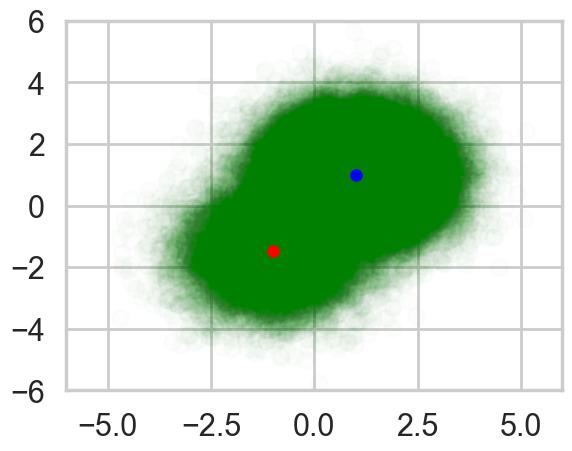

In [28]:
from copy import deepcopy

mu_0, sd_0 = means['mu_0'], sds['mu_0']
mu_1, sd_1 = means['mu_1'], sds['mu_1']
with sns.plotting_context('poster'):
    fig, ax = plt.subplots()
    plt.scatter(data[:, 0], data[:, 1], alpha=0.01, c='g')
    plt.scatter(mu_0[0], mu_0[1], c="r", s=50)
    plt.scatter(mu_1[0], mu_1[1], c="b", s=50)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)

The variance of the trace of ELBO is larger than without mini-batch because of the subsampling from the whole samples. 

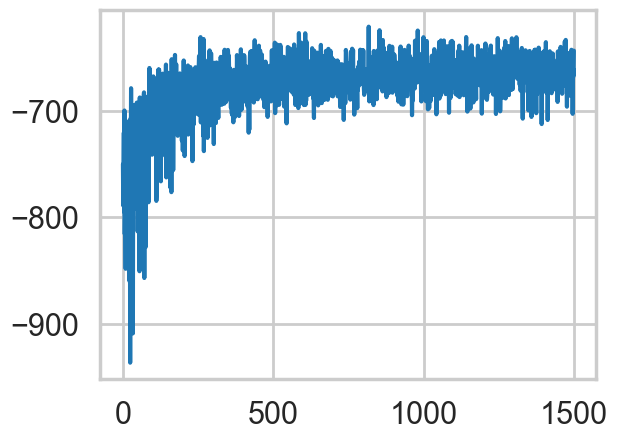

In [29]:
plt.plot(elbos);